<a href="https://colab.research.google.com/github/Lavanya-220948/AI_/blob/main/%5BMakke_Lavanya%5D_6_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Numerical computations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# TensorFlow
import tensorflow as tf

# Keras dataset
from tensorflow.keras.datasets import fashion_mnist

# One-hot encoding
from tensorflow.keras.utils import to_categorical

# CNN Model
from tensorflow.keras.models import Sequential

# CNN Layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Training callback
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
#to load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#to check the dataset shape
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


In [4]:
#displaying the class names
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

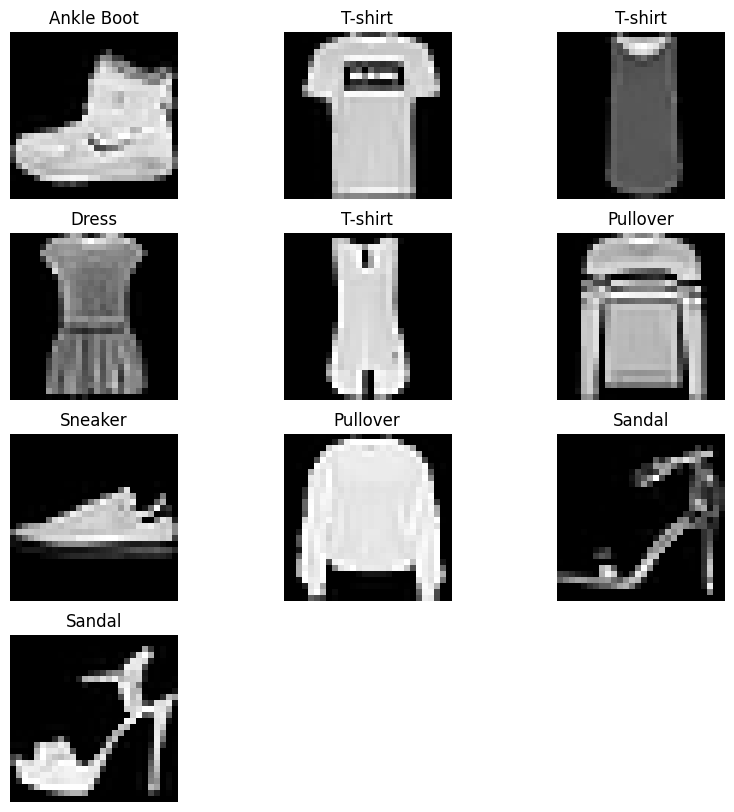

In [5]:
#displaying sample images, which helps to check whether the images and classes loaded perfectly
plt.figure(figsize=(10,10))

for i in range(10):

    plt.subplot(4,3,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.show()

In [6]:
#normizaling the image as the numbers range from 0 to 255, we are trying to convert them into 0 to 1
x_train = x_train / 255.0

x_test = x_test / 255.0

In [7]:
#reshaping the images, as cnn requires the image in the format of height,width,channels
'''and as the dataset contains gray scale images, it has 1 channel'''
x_train = x_train.reshape(60000,28,28,1)

x_test = x_test.reshape(10000,28,28,1)

In [8]:
print(x_test.shape)
print(x_train.shape)

(10000, 28, 28, 1)
(60000, 28, 28, 1)


In [9]:
#converting labels or class name into 0 and 1 using one hot encoding
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [10]:
#building the cnn model
# Create the CNN model
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Convert feature maps into a single vector
model.add(Flatten())

# Hidden Layer
model.add(Dense(
    units=128,
    activation='relu'
))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    units=10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
#display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#compiling the model
'''it displays the accuracy after every step, and loss function and optimization which helps to update the weights to
minimize the loss'''
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
#training the cnn using training data
'''And earlystopping method helps to stop the training when there is no improvement in validation loss'''
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.7891 - loss: 0.5820 - val_accuracy: 0.8545 - val_loss: 0.3795
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.8610 - loss: 0.3893 - val_accuracy: 0.8848 - val_loss: 0.3106
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.8775 - loss: 0.3363 - val_accuracy: 0.8917 - val_loss: 0.2957
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.8903 - loss: 0.2988 - val_accuracy: 0.9020 - val_loss: 0.2697
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.8976 - loss: 0.2799 - val_accuracy: 0.9060 - val_loss: 0.2577
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9061 - loss: 0.2575 - val_accuracy: 0.9030 - val_loss: 0.2646
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9126 - loss: 0.2393 - val_accuracy: 0.9107 - val_loss: 0.2511
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9153 -

In [14]:
#evaluating the model
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9111 - loss: 0.2573
Test Loss : 0.2572873532772064
Test Accuracy : 0.9110999703407288


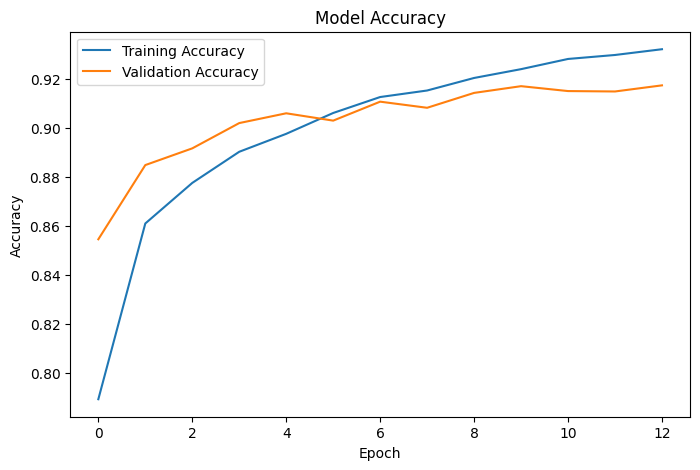

In [15]:
#plotting the increase of accuracy along with epochs
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

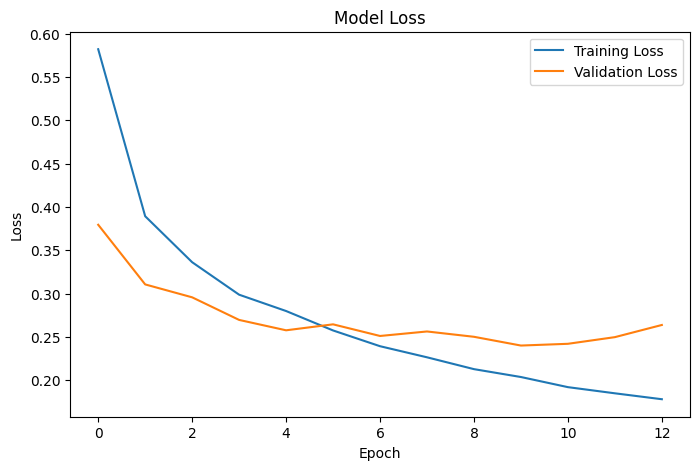

In [16]:
#plotting the loss function graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicted : Ankle Boot
Actual : Ankle Boot


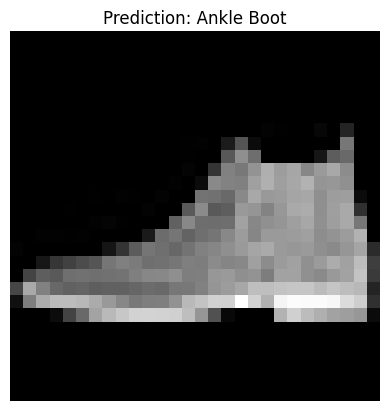

In [17]:
#predicting images
prediction = model.predict(x_test)

predicted_class = np.argmax(prediction[0])

actual_class = np.argmax(y_test[0])

print("Predicted :", class_names[predicted_class])

print("Actual :", class_names[actual_class])

plt.imshow(x_test[0].reshape(28,28), cmap="gray")

plt.title(
    f"Prediction: {class_names[predicted_class]}"
)

plt.axis("off")

plt.show()

In [18]:
#confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

In [19]:
# Predict probabilities
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded test labels back to integers
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


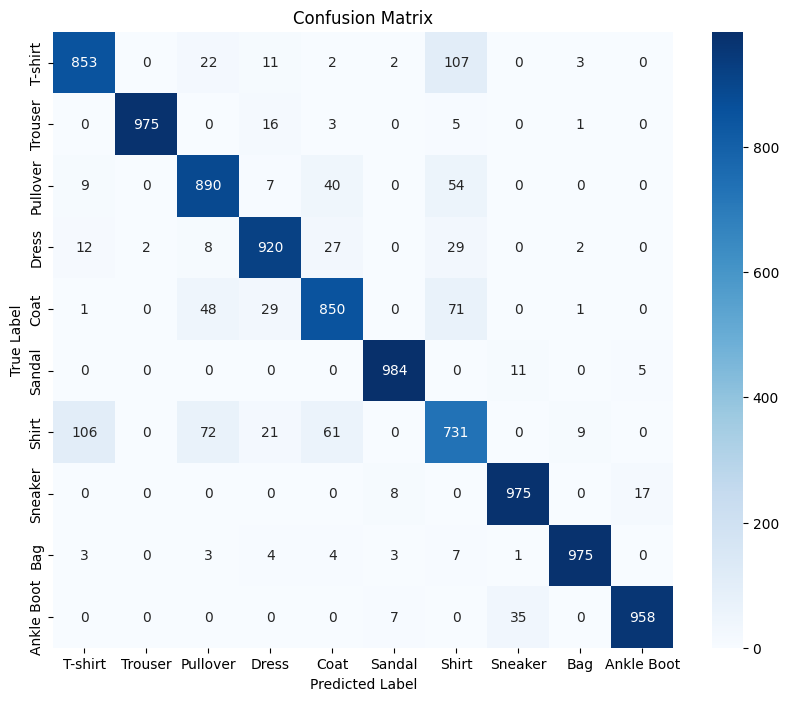

In [20]:
#creating confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

from above confusion matrix we can say, shirts were not predicted corrcetly

In [21]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.87      0.85      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.85      0.89      0.87      1000
       Dress       0.91      0.92      0.92      1000
        Coat       0.86      0.85      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.73      0.73      0.73      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle Boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


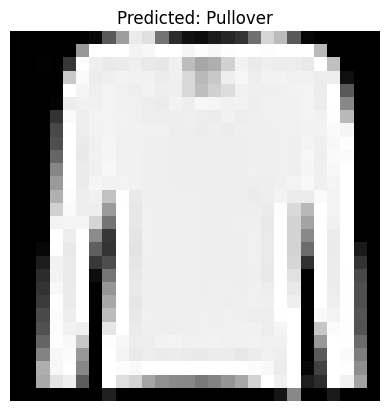

Actual : Pullover
Predicted : Pullover


In [22]:
#predicting images
index = 72

prediction = model.predict(
    x_test[index].reshape(1,28,28,1)
)

predicted_class = np.argmax(prediction)

actual_class = np.argmax(y_test[index])

plt.imshow(
    x_test[index].reshape(28,28),
    cmap="gray"
)

plt.title(f"Predicted: {class_names[predicted_class]}")

plt.axis("off")

plt.show()

print("Actual :", class_names[actual_class])

print("Predicted :", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


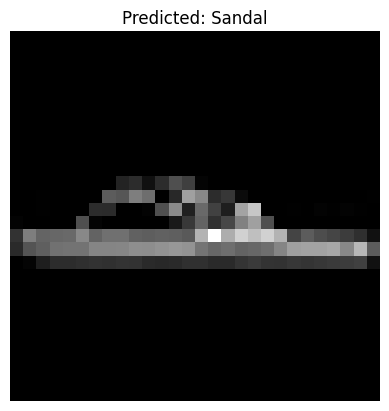

Actual : Sandal
Predicted : Sandal


In [23]:
index = 37

prediction = model.predict(
    x_test[index].reshape(1,28,28,1)
)

predicted_class = np.argmax(prediction)

actual_class = np.argmax(y_test[index])

plt.imshow(
    x_test[index].reshape(28,28),
    cmap="gray"
)

plt.title(f"Predicted: {class_names[predicted_class]}")

plt.axis("off")

plt.show()

print("Actual :", class_names[actual_class])

print("Predicted :", class_names[predicted_class])

In [24]:
#model performance
print("="*40)
print("Fashion MNIST CNN Performance")
print("="*40)

print(f"Training Accuracy : {history.history['accuracy'][-1]:.4f}")

print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

print(f"Test Accuracy : {test_accuracy:.4f}")

Fashion MNIST CNN Performance
Training Accuracy : 0.9322
Validation Accuracy : 0.9174
Test Accuracy : 0.9111


In [25]:
#to save the model
model.save("fashion_mnist_cnn.keras")

In [26]:
#to download
from google.colab import files

files.download("fashion_mnist_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
loaded_model = tf.keras.models.load_model("fashion_mnist_cnn.keras")

prediction = loaded_model.predict(x_test[:1])

print("Actual :", y_test[0])
print("Predicted :", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Actual : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Predicted : 9
